# Bekerja dengan Image

**DEM**: Digital Elevation Model
https://tanahair.indonesia.go.id/demnas/#/demnas

In [1]:
from osgeo import gdal
import matplotlib.pyplot as plt
import numpy as np

In [2]:
dataset=gdal.Open('cimanggung.tif')

In [3]:
band=dataset.GetRasterBand(1)
arr=band.ReadAsArray()

In [4]:
dataset.GetMetadata_Dict()

{'lat#actual_range': '{-8.001699835380901,-5.7488498353809}',
 'lat#long_name': 'latitude',
 'lat#units': 'degrees_north',
 'lon#actual_range': '{107.4985264609878,109.7508514609878}',
 'lon#long_name': 'longitude',
 'lon#units': 'degrees_east',
 'NC_GLOBAL#Conventions': 'COARDS, CF-1.5',
 'NC_GLOBAL#GMT_version': '5.3.2 (r17593) [64-bit]',
 'NC_GLOBAL#history': 'grdmath global.grd diff.grd ADD = final_topo.grd',
 'NC_GLOBAL#title': 'Produced by grdmath',
 'z#actual_range': '{-5.402652263641357,3421.426025390625}',
 'z#long_name': 'GDAL Band Number 1',
 'z#_FillValue': 'nan'}

In [5]:
print(arr.shape)

(3333, 3333)


In [7]:
print(arr) # ketinggian dari permukaan laut (mdpl)

[[606.47125 608.0085  609.33185 ... 503.9795  504.14178 504.2282 ]
 [607.08093 609.25165 611.10175 ... 502.57086 502.9971  503.32123]
 [607.64825 610.5204  613.03064 ... 500.6525  501.32632 501.86035]
 ...
 [663.1067  664.39813 664.9941  ... 733.3786  734.2346  735.5223 ]
 [663.4759  664.738   665.38306 ... 729.9979  730.613   731.7922 ]
 [663.7922  664.9142  665.527   ... 727.30786 727.735   728.82153]]


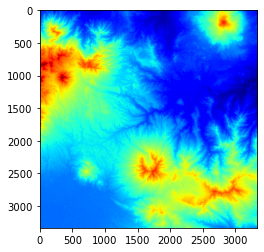

In [8]:
plt.imshow(arr,cmap='jet')

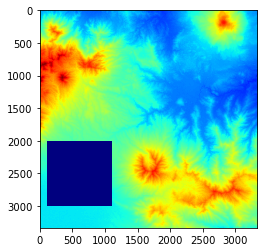

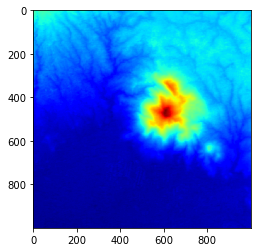

In [9]:
newarr=arr.copy()

# tanda titik dua (:) --> operator range
# lo:hi --> lo=>inclusive, hi=>exclusive
# 2000:3000 indeks 2000 s.d. 2999

newarr[2000:3000,100:1100] = 0
cmg=arr[2000:3000,100:1100]
plt.imshow(newarr, cmap='jet')
plt.show()
plt.imshow(cmg, cmap='jet')
plt.show()

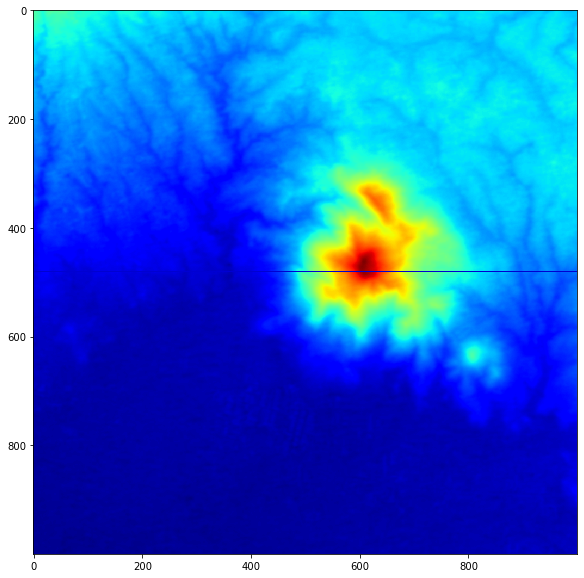

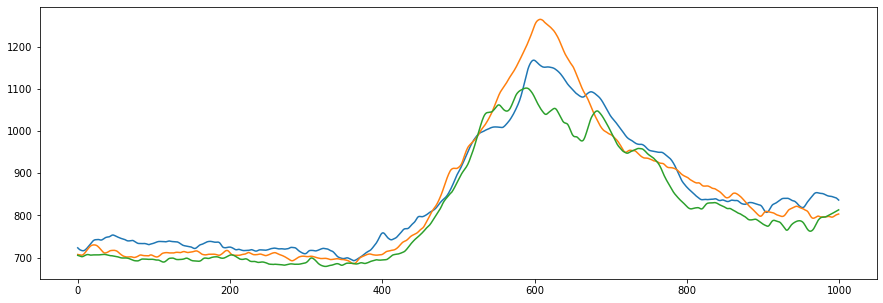

In [10]:
tcmg=cmg.copy()
stk=480
tcmg[stk,:]=700

tra=cmg[stk-50,:]
trb=cmg[stk,:]
trc=cmg[stk+50,:]

plt.rcParams['figure.figsize']=(10,10)
plt.imshow(tcmg,cmap='jet')
plt.show()
plt.rcParams['figure.figsize']=(15,5)
plt.plot(tra)
plt.plot(trb)
plt.plot(trc)
plt.show()

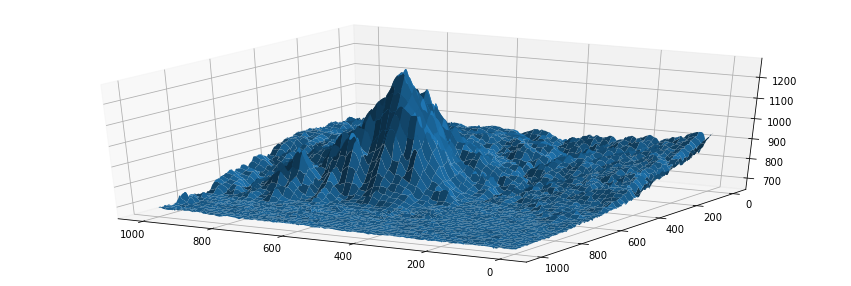

In [11]:
from mpl_toolkits import mplot3d
fig = plt.figure()
plt.rcParams['figure.figsize']=(20,20)
ax = plt.axes(projection='3d')
xx=np.arange(0,cmg.shape[0])
yy=np.arange(0,cmg.shape[1])
X, Y = np.meshgrid(xx, yy)
#ax.plot_wireframe(X, Y, cmg)
#ax.contour3D(X,Y,cmg)
ax.view_init(30,120)
ax.plot_surface(X, Y, cmg)
plt.show()
#, rstride=1, cstride=1,cmap='viridis', edgecolor='none')

In [12]:
type(arr)

numpy.ndarray

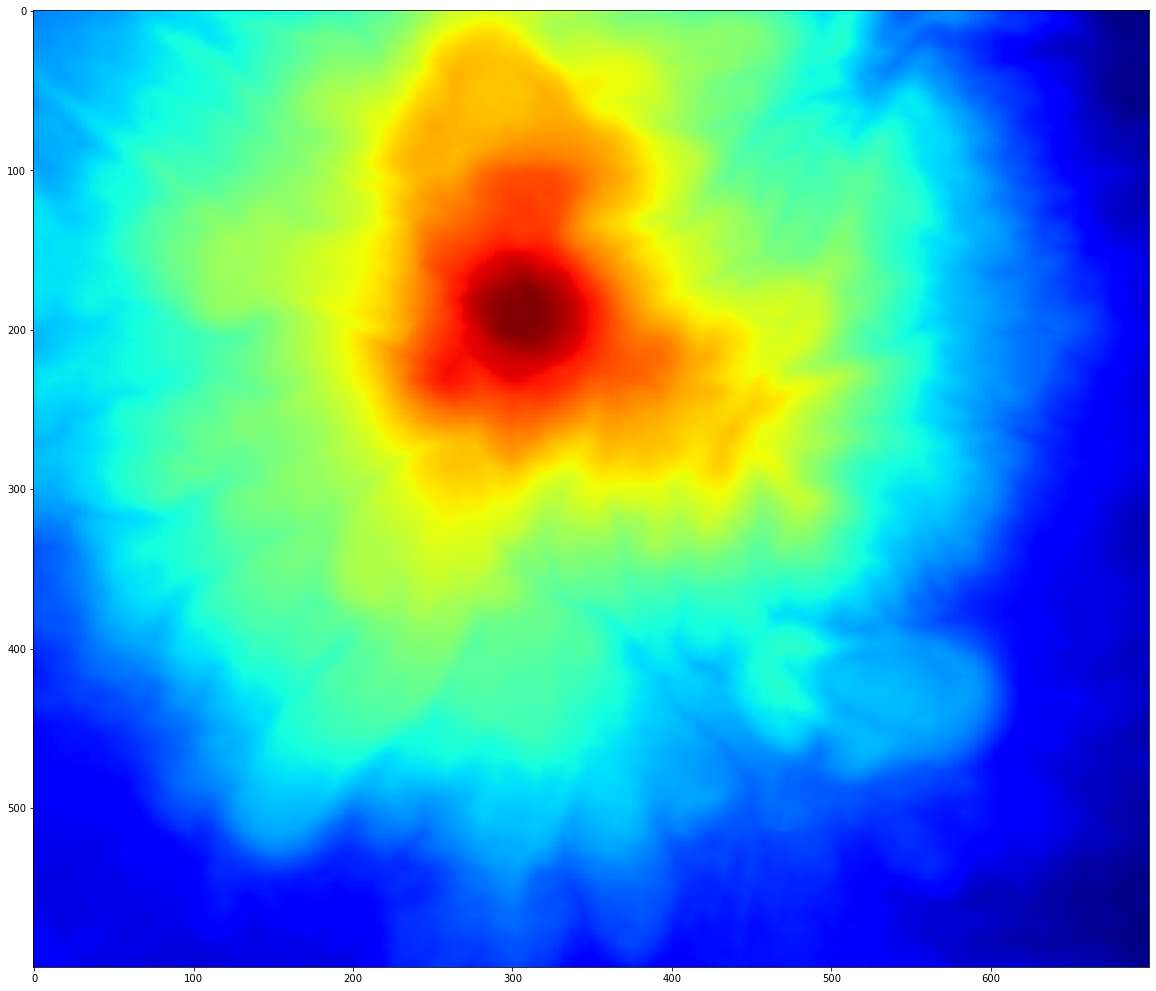

In [13]:
cup=arr[0:600,2500:3200]

plt.imshow(cup,cmap='jet')

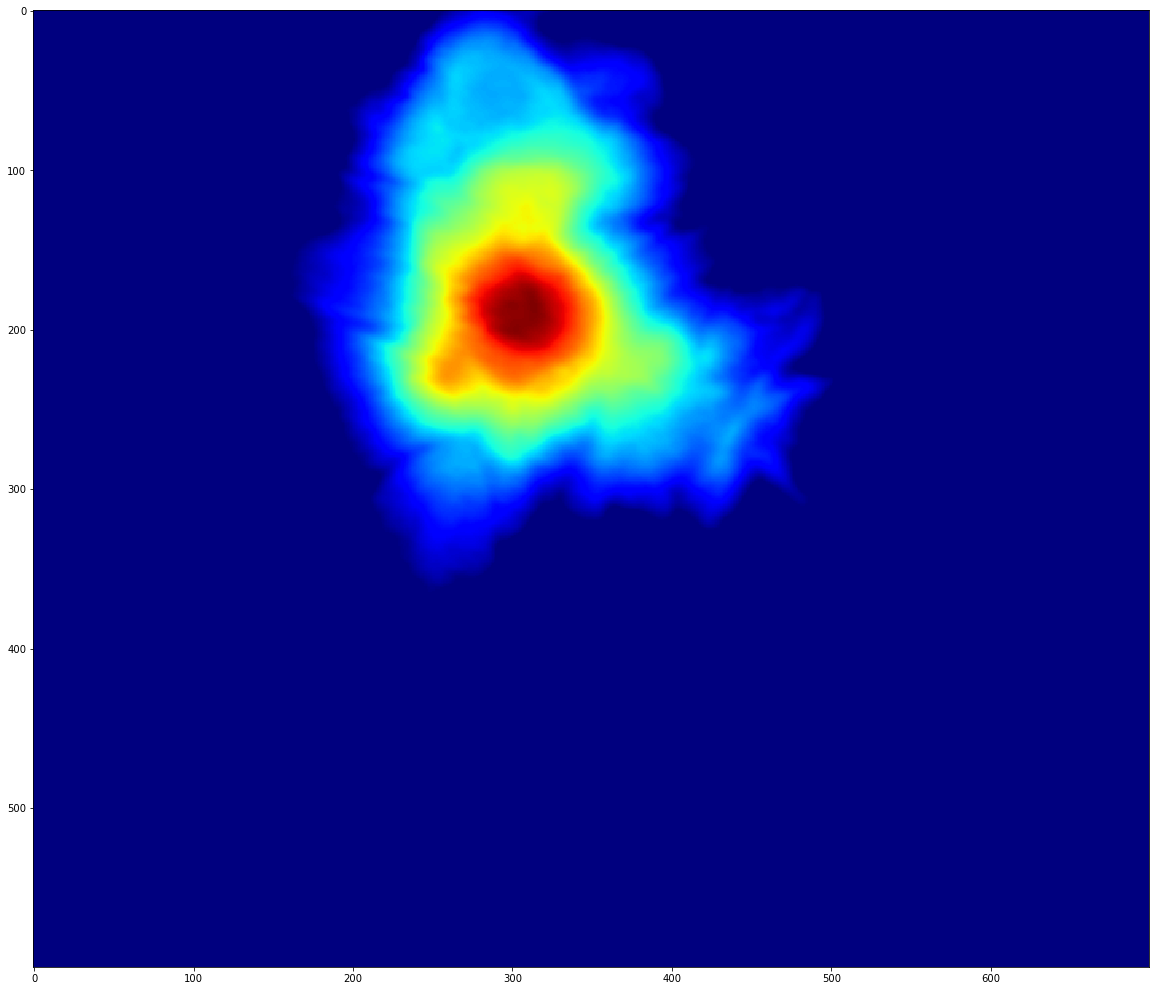

In [14]:
cupo=np.zeros(cup.shape)
for a in range(cup.shape[0]):
  for b in range(cup.shape[1]):
    if cup[a,b]<1200: cup[a,b]=0
    else: cup[a,b]-=1200
    
plt.imshow(cup,cmap='jet')